# PCA on the US Treasury yield curve

Principal component analysis of daily changes in Treasury par yields (1Y to 30Y, FRED, 2015 to 2024). The goal is to show that curve moves are low-dimensional: level, slope and curvature explain almost all variation, which is why curve risk is usually managed with a handful of factors instead of every tenor.

## Config

In [1]:
DATA_FILE = "treasury_par_yields_2015_2024.csv"
FRED_START, FRED_END = "2015-01-01", "2025-01-01"
FRED_CODES = {"DGS1": "1Y", "DGS2": "2Y", "DGS3": "3Y", "DGS5": "5Y", "DGS7": "7Y", "DGS10": "10Y", "DGS20": "20Y", "DGS30": "30Y"}
N_COMPONENTS = 3
BP = 100  # percent to basis points

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

if os.path.exists(DATA_FILE):
    yields = pd.read_csv(DATA_FILE, index_col="date", parse_dates=True)
else:
    import pandas_datareader.data as web
    yields = web.DataReader(list(FRED_CODES), "fred", FRED_START, FRED_END).dropna()
    yields.columns = [FRED_CODES[c] for c in yields.columns]
TENOR_COLUMNS = list(yields.columns)
print(yields.shape, yields.index.min().date(), yields.index.max().date())
yields.tail()

(2501, 8) 2015-01-02 2024-12-31


,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
date,,,,,,,,
2024-12-24,4.24,4.29,4.36,4.43,4.52,4.59,4.84,4.76
2024-12-26,4.23,4.30,4.35,4.42,4.49,4.58,4.83,4.76
2024-12-27,4.20,4.31,4.36,4.45,4.53,4.62,4.89,4.82
2024-12-30,4.17,4.24,4.29,4.37,4.46,4.55,4.84,4.77
2024-12-31,4.16,4.25,4.27,4.38,4.48,4.58,4.86,4.78


## Daily yield changes in basis points
PCA is run on changes, not levels, because yield levels are non-stationary.

In [3]:
changes = yields.diff().dropna() * BP
changes.describe().loc[["mean", "std", "min", "max"]].round(2)

,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
mean,0.16,0.14,0.13,0.11,0.10,0.10,0.10,0.08
std,4.03,5.19,5.43,5.58,5.63,5.39,5.24,5.17
min,-60.00,-57.00,-43.00,-32.00,-31.00,-30.00,-26.00,-31.00
max,34.00,34.00,35.00,31.00,29.00,29.00,35.00,29.00


## Fit PCA on the covariance of changes
Changes are centered but not rescaled, so the components are in basis point units and reflect each tenor's own volatility.

In [4]:
pca = PCA(n_components=N_COMPONENTS).fit(changes)
explained = pd.Series(pca.explained_variance_ratio_, index=[f"PC{i + 1}" for i in range(N_COMPONENTS)])
print((explained * 100).round(2).astype(str) + "%")
print("Cumulative:", round(explained.sum() * 100, 2), "%")

PC1    84.94%
PC2    11.04%
PC3     2.21%
dtype: object
Cumulative: 98.18 %


In [5]:
loadings = pd.DataFrame(pca.components_.T, index=TENOR_COLUMNS, columns=explained.index)
loadings.round(3)

,PC1,PC2,PC3
1Y,0.210,-0.444,0.794
2Y,0.334,-0.463,-0.032
3Y,0.373,-0.332,-0.251
5Y,0.401,-0.116,-0.322
7Y,0.408,0.066,-0.230
10Y,0.385,0.222,-0.051
20Y,0.348,0.425,0.215
30Y,0.330,0.479,0.318


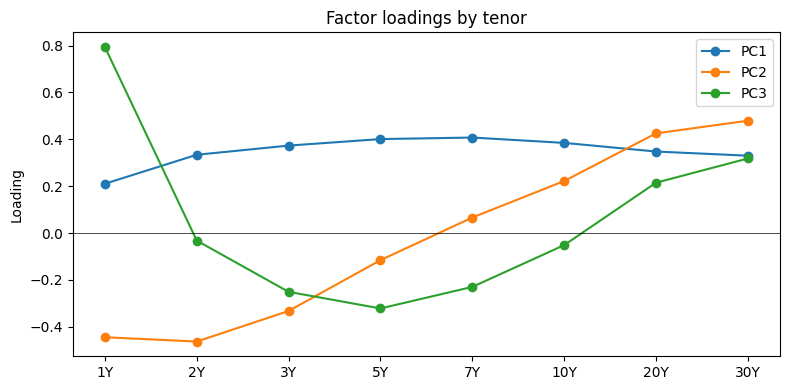

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
loadings.plot(ax=ax, marker="o")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Factor loadings by tenor")
ax.set_ylabel("Loading")
plt.tight_layout(); plt.show()

## Interpretation
- **PC1 (level):** loadings share one sign across tenors, a parallel shift of the curve.
- **PC2 (slope):** loadings change sign between short and long tenors, a steepening or flattening.
- **PC3 (curvature):** belly moves against the wings.

Check the signs in the table above: the sign of a component is arbitrary, so look at the pattern, not the direction.

## Reconstruct the curve changes from 3 components and measure the residual

In [7]:
scores = pca.transform(changes)
reconstructed = pd.DataFrame(pca.inverse_transform(scores), index=changes.index, columns=TENOR_COLUMNS)
residual = changes - reconstructed
rmse_by_tenor = np.sqrt((residual ** 2).mean()).round(3)
print("Reconstruction RMSE (bp) by tenor:"); print(rmse_by_tenor)
print("Share of total variance left unexplained:", round(float(residual.var().sum() / changes.var().sum()) * 100, 2), "%")

Reconstruction RMSE (bp) by tenor:
1Y     0.483
2Y     1.027
3Y     0.771
5Y     0.673
7Y     0.697
10Y    0.629
20Y    0.593
30Y    0.643
dtype: float64
Share of total variance left unexplained: 1.82 %


## Stability check: do the loadings change by period?
Refit on 2015 to 2019 and 2020 to 2024 and compare PC1 and PC2 explained variance.

In [8]:
rows = []
for label, (lo, hi) in {"2015-2019": ("2015", "2019"), "2020-2024": ("2020", "2024")}.items():
    sub = changes.loc[lo:hi]
    p = PCA(n_components=N_COMPONENTS).fit(sub)
    rows.append(pd.Series(p.explained_variance_ratio_, index=explained.index, name=label))
pd.DataFrame(rows).mul(100).round(2)

,PC1,PC2,PC3
2015-2019,87.68,7.92,2.08
2020-2024,84.53,11.72,2.14


## Limitations
- Par yields, not zero rates, and only eight tenors, so the shape of the curvature factor is coarse.
- The PCA is on unscaled changes, so high-volatility tenors dominate the early components.
- Principal components describe historical covariance; they do not predict future curve moves.